# Dynamic policy compression

The previous notebooks have highlighted that state dependent action priors are able to account for a significant amount of participants behaviour, outperforming Ott's hybrid model and therefore offering insights about the computational mechanisms for the combination of forward planning with previously learned heuristics. However, in the previous notebooks, we have kept the action prior fixed throughout the task. It is however likely that these get dynamically updated based on the responses given over the course of the task.

If participants do adopt such a dynamic prior update process, this might explain why our models so far don't fit the data so well in the absence of offer specific regressors. For example, when taking the case of offer 1, for which participants might start with a prior of 0.25 of acceptance, if the decision value associated on average with offer 1 is also close to 0.25, then the action frequency in this group of states will stay the same over time. But now if we think of offer 2, for which the decision value might be a bit higher but the initial action prior also of 0.25, then we would expect the action prior for this set of states to shift up. Same idea goes for offer 3 and 4. If that is the case, action priors will converge to different values for the different offers, which might take into account the offer specific biases that are observed in the data, without requiring the extra constant.

A more general framework that seems to be emerging from the result is that participants might be keeping counts of their responses not in every single state, but instead along specific dimensions of the state space (offer, costs, transitions...), which is more economical. Then, when faced with a specific state, which is always a combination of all these aspects, then they simply combine the prior across all the dimensions. For example, they might have the priors of 0.25 when offer is 1, prior of 0.75 when cost is 1, prior of 0.5 when transition is cc=2 and fc=2, such that when they encounter such a state, their prior is the weighted sum of all of those. This is what we will be testing in this notebook.

Specifically, we will test that idea by using a moving average update rule:

$$
P(a=1)_{t+1} = \frac{P(a=1)_t + \lambda p(a=1)_{t+1}}{1+\lambda}
$$

Where $p(a=1)$ is simply the action taken at time $t$ since we only have only 2 possible actions. $\lambda$ is a learning constant, which we will set to 0.1 to start with.  Importantly, we will keep updating this marginal probability separately for each factors of the MDP. For the energy dimension, since we not found a good prior in the previous notebooks, we will set it to 0.5. 

# Preparing the data

In [7]:
import numpy as np
import pandas as pd
import os
from stabst.models import policy_compression_model
from scipy.special import expit
from stabst.MarkovDecisionProcess import MDP
from stabst.TaskConfig import LimitedEnergyTask
import matplotlib.pyplot as plt
import arviz as az
import bambi as bmb
from scipy.special import logit
import copy


# ===================================================================
# Loading the raw data:
data = pd.read_csv("../../data/raw_data/all_participants_data.csv", on_bad_lines='skip')

# ===================================================================
# Data preprocessing:
# Remove nans:
data = data.dropna()
# Flip responses: 1 = accept:
data["response"] = np.abs(data["response"] - 1)
# Make trial 1 based
data["trial"] = data["trial"] + 1
# Generate future cost based on the transitions:
transitions_costs = {
    0: [1, 1],
    1: [2, 1],
    2: [1, 2],
    3: [2, 2]
}
data["fc"] = [transitions_costs[row["transition"]][1] for _, row in data.iterrows()]

# ===================================================================
# Task MDP:
# Create the task and its parameters (transition probability, reward...):
task = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4)
task.build()

# Create full MDP and compute solution for later reference:
gamma = 0.99
task_mdp = MDP(task.states, task.tp, task.r, gamma, s2i=task.s2i)
V_full, Q_full = task_mdp.backward_induction()

# Add decision values to the dataframe:
dv = Q_full[:, 1] - Q_full[:, 0]
# Loop through each trial to set DV:
dv_trials = []
for trial_i, trial in data.iterrows():
    e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
    fc = transitions_costs[trial.transition][1]
    dv_trials.append(dv[task.s2i[(e, o, cc, fc, t)]])
data['dv'] = dv_trials

# Compute offer specific decision value regressors:
data['dv_23'] = data['dv'].to_numpy() * (data['is_2'].to_numpy() + data['is_3'].to_numpy())
data['dv_14'] = data['dv'].to_numpy() * (data['is_1'].to_numpy() + data['is_4'].to_numpy())

# Compute various priors over actions:

We compute both fixed priors like in the previous notebooks and dynamic priors that get updated upon each decision, with a learning rate $\lambda=0.1$. 

In [8]:
# Initialize the priors:
action_priors = {
    "offer": [0.25, 0.25, 0.75, 0.75],
    "cost": [0.75, 0.25],
    "energy": [0.5] * 7,
    "transitions": [0.5, 0.25, 0.75, 0.5]
}
lbda = 0.1

data2 = []
# Looping separately through each subject:
for sub in list(data['vpn'].unique()):
    # Initialize single trial prior:
    p_a_offer = []
    p_a_costs = []
    p_a_energy = []
    dynamic_pa = copy.deepcopy(action_priors)

    # Extract subject's data:
    sub_data = data[data['vpn'] == sub]
    for trial_i, trial in sub_data.iterrows():
        e, o, cc, trans = trial.energy, trial.reward, trial.energy_cost, trial.transition
        # Fixed priors
        sub_data.loc[trial_i, 'P(A)-offer_fixed'] = action_priors["offer"][int(o)-1]
        sub_data.loc[trial_i, 'P(A)-costs_fixed'] = action_priors["cost"][int(cc)-1]
        sub_data.loc[trial_i, 'P(A)-energy_fixed'] = action_priors["energy"][int(e)]
        sub_data.loc[trial_i, 'P(A)-transitions_fixed'] = action_priors["transitions"][int(trans)]

        # Dynamic priors
        sub_data.loc[trial_i, 'P(A)-offer'] = dynamic_pa["offer"][int(o)-1]
        sub_data.loc[trial_i, 'P(A)-costs'] = dynamic_pa["cost"][int(cc)-1]
        sub_data.loc[trial_i, 'P(A)-energy'] = dynamic_pa["energy"][int(e)]
        sub_data.loc[trial_i, 'P(A)-transitions'] = dynamic_pa["transitions"][int(trans)]

        # Update the marginal action probabilities for the next trial
        dynamic_pa["offer"][int(o)-1] = (dynamic_pa["offer"][int(o)-1] + lbda * trial.response) / (1 + lbda)
        dynamic_pa["cost"][int(cc)-1] = (dynamic_pa["cost"][int(cc)-1] + lbda * trial.response) / (1 + lbda)
        dynamic_pa["energy"][int(e)] = (dynamic_pa["energy"][int(e)] + lbda * trial.response) / (1 + lbda)
        dynamic_pa["transitions"][int(trans)] = (dynamic_pa["transitions"][int(trans)] + lbda * trial.response) / (1 + lbda)
    # Add to the data:
    data2.append(sub_data)
data = pd.concat(data2).reset_index(drop=True)
# Convert them all to logit:
data["logitP_A_offer"] = logit(data['P(A)-offer'].to_numpy())
data["logitP_A_costs"] = logit(data['P(A)-costs'].to_numpy())
data["logitP_A_energy"] = logit(data['P(A)-energy'].to_numpy())
data["logitP_A_transitions"] = logit(data['P(A)-transitions'].to_numpy())

data["logitP_A_offer_fixed"] = logit(data['P(A)-offer_fixed'].to_numpy())
data["logitP_A_costs_fixed"] = logit(data['P(A)-costs_fixed'].to_numpy())
data["logitP_A_energy_fixed"] = logit(data['P(A)-energy_fixed'].to_numpy())
data["logitP_A_transitions_fixed"] = logit(data['P(A)-transitions_fixed'].to_numpy())

## Plotting the logit P(A) as a function of time
To illustrate what the dynamic prior looks like, we will plot the data from a single subject separately for eaech of the aspects for which we are specifying priors. If participants behaviour does indeed reflect the mixture between the prior and the decision value, we would expect the moving average of the prior value to gradually converge to some fixed point. 

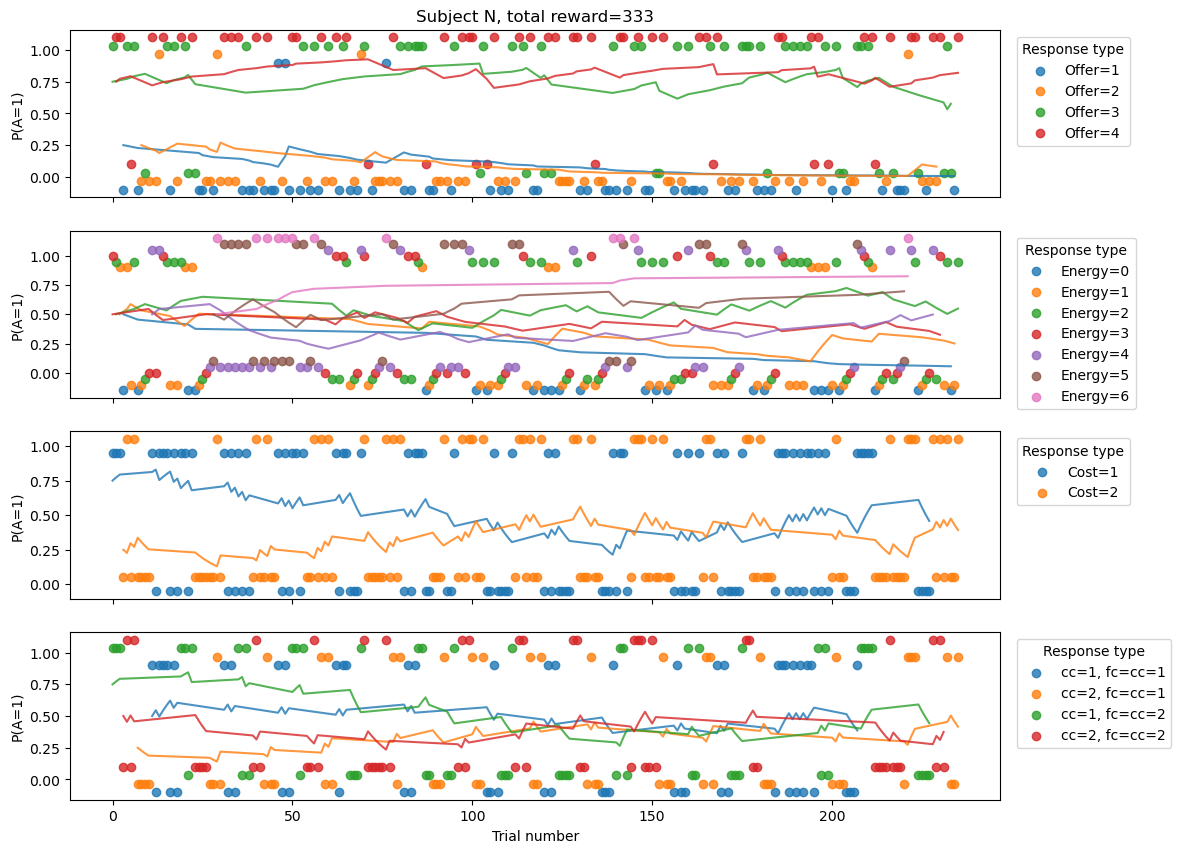

In [9]:
# Extract the data of the first subject:
sub_data = data[data["vpn"] == data["vpn"].unique()[0]].copy().reset_index(drop=True)

fig, ax = plt.subplots(4, figsize=(12, 10), sharex=True)

# Offer:
jitters = np.linspace(-0.1, 0.1, 4)
for i, offer in enumerate(sub_data["reward"].sort_values().unique()):
    ax[0].scatter(sub_data[sub_data["reward"] == offer].index, 
                  sub_data[sub_data["reward"] == offer]["response"] + jitters[i], 
                  alpha=0.8,
                  label=f"Offer={offer}")
    ax[0].plot(sub_data[sub_data["reward"] == offer].index, sub_data[sub_data["reward"] == offer]["P(A)-offer"], alpha=0.8)
ax[0].legend(title='Response type', bbox_to_anchor=(1.01, 1), loc='upper left')
ax[0].set_ylabel("P(A=1)")
ax[0].set_title(f"Subject N, total reward={sub_data["points_after"].to_numpy()[-1]}")

# Energy:
jitters = np.linspace(-0.15, 0.15, 7)
for i, energy in enumerate(sub_data["energy"].sort_values().unique()):
    ax[1].scatter(sub_data[sub_data["energy"] == energy].index, 
                  sub_data[sub_data["energy"] == energy]["response"] + jitters[i], 
                  alpha=0.8,
                  label=f"Energy={energy}")
    ax[1].plot(sub_data[sub_data["energy"] == energy].index, sub_data[sub_data["energy"] == energy]["P(A)-energy"], alpha=0.8)
ax[1].legend(title='Response type', bbox_to_anchor=(1.01, 1), loc='upper left')
ax[1].set_ylabel("P(A=1)")

# Costs:
jitters = np.linspace(-0.05, 0.05, 2)
for i, cost in enumerate(sub_data["energy_cost"].sort_values().unique()):
    ax[2].scatter(sub_data[sub_data["energy_cost"] == cost].index, 
                  sub_data[sub_data["energy_cost"] == cost]["response"] + jitters[i], 
                  alpha=0.8,
                  label=f"Cost={cost}")
    ax[2].plot(sub_data[sub_data["energy_cost"] == cost].index, sub_data[sub_data["energy_cost"] == cost]["P(A)-costs"], alpha=0.8)
ax[2].legend(title='Response type', bbox_to_anchor=(1.01, 1), loc='upper left')
ax[2].set_ylabel("P(A=1)")
# Transition:
jitters = np.linspace(-0.1, 0.1, 4)
for i, transition in enumerate(sub_data["transition"].sort_values().unique()):
    ax[3].scatter(sub_data[sub_data["transition"] == transition].index, 
                  sub_data[sub_data["transition"] == transition]["response"] + jitters[i], 
                  alpha=0.8,
                  label=f"cc={transitions_costs[transition][0]}, fc=cc={transitions_costs[transition][1]}")
    ax[3].plot(sub_data[sub_data["transition"] == transition].index, sub_data[sub_data["transition"] == transition]["P(A)-transitions"], alpha=0.8)
ax[3].legend(title='Response type', bbox_to_anchor=(1.01, 1), loc='upper left')
ax[3].set_ylabel("P(A=1)")
ax[3].set_xlabel("Trial number");



As we can see, the probability of accepting large offer seems to never move too far away from 1 (always accept), while for low offers, it slowly moves towards 0 (for this participant at least). For the energy, we can see that the probability of accepting converges towards 0 for e=0, and towards 1 for e=6. Inbetween, things are a bit all over the place. 

Interestingly, for the costs, there does not seem to be any convergence towards a fixed point. Rather, the probability of accepting seem to decrease and then increase again for low costs, and the opposite seems to be happening for high costs (in this specific participant). I've dug deeper into this. It is not specific to this participant but rather seems to be consistend across participants. The reason for this particular pattern is the structure of the task. Indeed, costs and offers sequences are fixed across participants. And it turns out that the particular sequence that was chosen tends to have lower offers at low cost in the middle of the experiment:

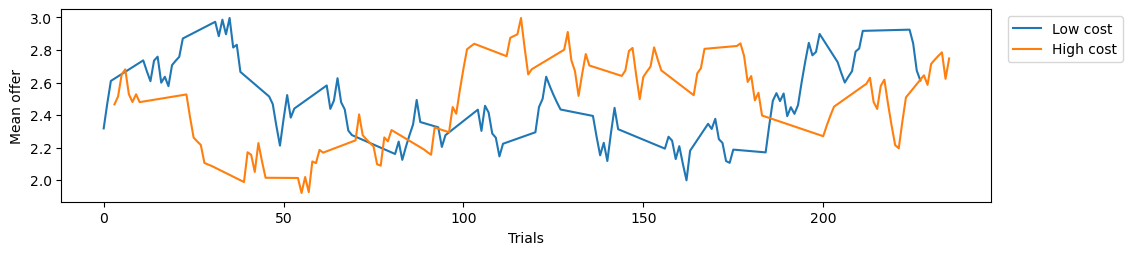

In [10]:
mean_offer = 9/4
sub_data_low_costs = data[(data["vpn"] == data["vpn"].unique()[0]) & (data["energy_cost"] == 1)].copy()
sub_data_high_costs = data[(data["vpn"] == data["vpn"].unique()[0]) & (data["energy_cost"] == 2)].copy()
offer_lc = []
offer_hc = []
for trial_i, trial in sub_data_low_costs.iterrows():
    offer_lc.append((mean_offer + 0.1 * trial.reward) / 1.1)
    mean_offer = offer_lc[-1]
for trial_i, trial in sub_data_high_costs.iterrows():
    offer_hc.append((mean_offer + 0.1 * trial.reward) / 1.1)
    mean_offer = offer_hc[-1]
fig, ax = plt.subplots(figsize=(12, 2.5))
ax.plot(sub_data_low_costs.index, offer_lc, label="Low cost")
ax.plot(sub_data_high_costs.index, offer_hc, label="High cost")
ax.set_xlabel("Trials")
ax.set_ylabel("Mean offer")
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left');


Finally, in terms of transitions, surprisingly,the probability fo accepting seem to be converging a bit towards equal probability regardless of the costs transitions, which is a bit surprising as well but probably has to do with the sequences as well. 

# Model fitting:

In [11]:
traces = {}

# ===================================================================
# Hybrid mixture model (reference)
hybrid_prior_mixture_model = bmb.Model(
    "response ~ dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_offer_fixed + logitP_A_costs_fixed + logitP_A_transitions_fixed + "
    "(dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + logitP_A_offer_fixed + logitP_A_costs_fixed + logitP_A_transitions_fixed|vpn)", 
    data, 
    family="bernoulli")
traces['hybrid_prior_mixture_model'] = hybrid_prior_mixture_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
    quiet=True
)

# ===================================================================
# Hybrid mixture model with dynamic action priors:
hybrid_dynamic_prior_model = bmb.Model(
    "response ~ dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_offer + logitP_A_costs + logitP_A_transitions + logitP_A_energy +"
    "(dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + logitP_A_offer + logitP_A_costs + logitP_A_transitions + logitP_A_energy|vpn)", 
    data, 
    family="bernoulli")
traces['hybrid_dynamic_prior_model'] = hybrid_dynamic_prior_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
    quiet=True
)

# ===================================================================
# Simpler model with only dynamic priors:
dynamic_prior_model = bmb.Model(
    "response ~ dv + logitP_A_offer + logitP_A_costs + logitP_A_transitions + logitP_A_energy +"
    "(dv + logitP_A_offer + logitP_A_costs + logitP_A_transitions + logitP_A_energy|vpn)", 
    data, 
    family="bernoulli")
traces['dynamic_prior_model'] = dynamic_prior_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
    quiet=True
)

# ===================================================================
# Hybrid mixed dynamic and fixed priors
hybrid_mixed_priors = bmb.Model(
    "response ~ dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_offer + logitP_A_energy + logitP_A_costs_fixed + logitP_A_transitions_fixed + "
    "(dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + logitP_A_offer + logitP_A_energy + logitP_A_costs_fixed + logitP_A_transitions_fixed|vpn)", 
    data, 
    family="bernoulli")
traces['hybrid_mixed_priors'] = hybrid_mixed_priors.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
    quiet=True
)



Modeling the probability that response==1
Modeling the probability that response==1
Modeling the probability that response==1
Modeling the probability that response==1


Modeling the probability that response==1
/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observa

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
hybrid_mixed_priors,0,-1556.318761,205.360383,0.000000,0.585609,50.403746,0.000000,True,log
hybrid_mixed_priors_no_energy,1,-1561.218787,207.794523,4.900026,0.044213,50.884835,4.879500,True,log
hybrid_prior_mixture_model,2,-1572.199884,214.294126,15.881123,0.291973,50.911774,9.026844,True,log
hybrid_dynamic_prior_model,3,-1633.606858,190.224394,77.288097,0.000000,51.002215,11.458526,True,log
dynamic_prior_model,4,-1708.739051,140.424601,152.420290,0.078204,50.769093,19.167905,True,log


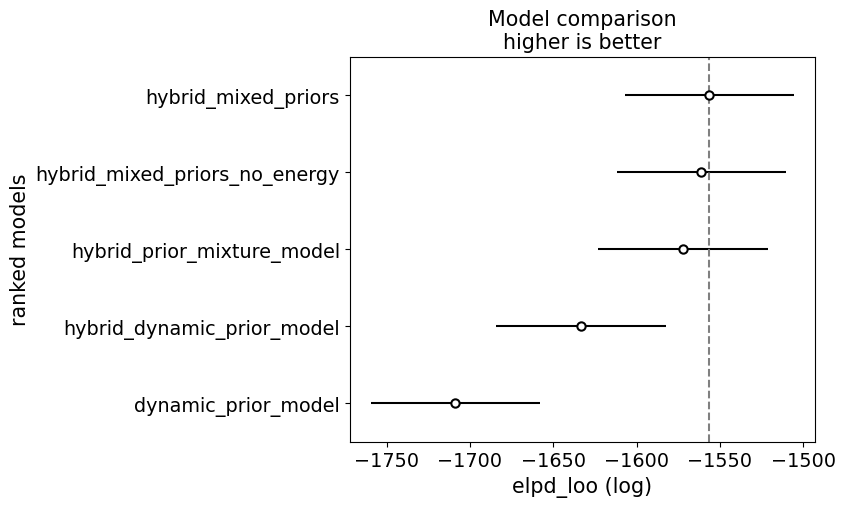

In [12]:

# ===================================================================
# Hybrid mixed dynamic and fixed priors
hybrid_mixed_priors_no_energy = bmb.Model(
    "response ~ dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_offer + logitP_A_costs_fixed + logitP_A_transitions_fixed + "
    "(dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + logitP_A_offer + logitP_A_costs_fixed + logitP_A_transitions_fixed|vpn)", 
    data, 
    family="bernoulli")
traces['hybrid_mixed_priors_no_energy'] = hybrid_mixed_priors_no_energy.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
    quiet=True
)

# Compare the models:
model_comparison = az.compare(traces)
az.plot_compare(model_comparison);
model_comparison

Unfortunately, our idea does not seem to  work. We can idneed see that the hybrid model with fixed priors performs better than the same model with dynamic priors. The model with only dynamic priors doesn't fit the data the best. When we make only some of the priors being dynamic, we get a similar fit to when we have when we just use only fixed priors.

# Discussions

There are a couple of things that could explain it. First, perhaps our initial values are wrong. Alternatively, we have selected an arbitrary learning constant of 0.1, which could be wrong. However, I am not optimistic that trying different values will lead us anywhere. Indeed, regarding the learning rate, we would expect that even if it is off, having some should do better than having none, which is not the case here.

An alternative explanation is that the simple idea that priors get combined as a weighted average might be wrong. Indeed, the underlying assumption under these models is that the priors associated with each state variables are independent from each other. Indeed, if we are at offer 3 (P(A=1)=0.75) with current cost 1 (P(A=1)=0.75), the models assume that the combined üprior will be 0.75. In contrast, if we are at at offer 1 (P(A=1)=0.25) with current cost 1 (P(A=1)=0.75), the prior will be something in between 0.25 and 0.75. It is however possible (if not likely) that action priors are instead related to specific combinations of the state variables in a way that isn't captured by a simple linear combination of each. But then, if participants have to define a prior for every single state, we are loosing the advantage of policy compression and how it enables to make large problems more tractable. There are two options: (1) the priors are defined along only a subset of the possible combinations and (2) the operation for combining the priors of each variable is not linear. For (1), the difficulty is to find exactly which variables are ignored, which is essentially back to square 1. For (2), the question is which could be the exact operation used. 

Yet another possible explanation, though that migh reflect a misunderstanding on my end from policy compression, is that simply fitting the models we have fitted misses something compared to what has been done in the literature. As we have seen in the very first notebook, when trying to optimize the solution to the MDP under resources constraints, the optimal policy becomes:

$$
\pi(a|s) \propto e^{\beta Q(s,a) + log(P(a))}
$$

Which is why we have fitted participants behaviour using a mixture between Q(s, a) and P(a). However, in most papers describing the idea of policy compression, the data are not fitted in the same way we have fitted them. Instead, they are computing the optimal policy at various levels of constraint (different beta values) and fitting that instead. These two approach might be equivalent, not sure. These might not be, as a lot of these papers go the extra mile of coming up with quite complex reinforcement learning techniques to compute pi under policy compression rather than just sticking to already established techniques to compute Q and adding the prior afterwards. According to these papers, when computing the optimal policy under constraint, the entropy of the action at each state decreases with increase beta, though not uniformely. Some states do remain equally uncertain, while others become more and more certain, which aligns with how participants behave in the intermediate and extreme offers respectively. To further dig into this ideas, I will conduct additional analysis, computing the optimal policy under different levels of constraint, in a way that is very similar to what I have done for the state abstraction approaches we have tested. 